# 01e – Pre vs Post All-Star

Objetivo: comparar rendimiento Pre vs Post All-Star.


## Configuración

Cargamos librerías principales de análisis, configuramos estilo de gráficos y definimos rutas relativas. Las carpetas de salida se crean automáticamente para guardar tablas y figuras generadas en el notebook.

---


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)

NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[3]
DATA_DIR = PROJECT_ROOT / "00_data"
FIGURES_DIR = PROJECT_ROOT / "02a_reports" / "figures" / "pre_post_allstar"
TABLES_DIR = PROJECT_ROOT / "02a_reports" / "tables" / "pre_post_allstar"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

INTERMEDIATE_PATH = (
    DATA_DIR
    / "00b_intermediate"
    / "team_dashboard"
    / "general_splits"
    / "2024-25"
    / "Regular Season"
    / "team_dashboard__general_splits.parquet"
)
DATASET_SEGMENT_ID = 4
SEASON_TARGET = "2024-25"
TEAM_FILTER = None  # Ejemplo: "Boston Celtics"

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Parquet intermedio: {INTERMEDIATE_PATH}")
print(f"Segmento dataset objetivo: {DATASET_SEGMENT_ID}")
print(f"Temporada objetivo: {SEASON_TARGET}")
print(f"Filtro de equipo: {TEAM_FILTER}")


Proyecto: /Users/pablo/Documents/BigData/BasketballAnalysis
Parquet intermedio: /Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00b_intermediate/team_dashboard/general_splits/2024-25/Regular Season/team_dashboard__general_splits.parquet
Segmento dataset objetivo: 4
Temporada objetivo: 2024-25
Filtro de equipo: None


## Carga y filtrado de datos

Leemos el parquet consolidado, homogenizamos los nombres de columnas para acceder sin problemas (`lower()`) y filtramos el dataset correspondiente al split Pre/Post All-Star (`dataset == 4`). Si se define `TEAM_FILTER`, se restringe el análisis a una franquicia concreta.

---


In [6]:
general_df = pd.read_parquet(INTERMEDIATE_PATH)

col_lookup = {col.lower(): col for col in general_df.columns}

def get_col(name: str) -> str:
    key = name.lower()
    if key not in col_lookup:
        raise KeyError(f"Columna requerida no encontrada: {name}")
    return col_lookup[key]

df = general_df.copy()

season_col = get_col("season") if "season" in col_lookup else get_col("season_year")
if TEAM_FILTER:
    df = df[df[get_col("team_name")] == TEAM_FILTER].copy()

if season_col in df.columns:
    df = df[df[season_col].astype(str).str.contains(SEASON_TARGET)].copy()

segment_col = get_col("source_dataset")
df_seg = df.query(f"`{segment_col}` == @DATASET_SEGMENT_ID").copy()

EXPECTED_COLUMNS = [
    "GROUP_SET", "GROUP_VALUE", "SEASON_YEAR", "GP", "W", "L", "W_PCT", "MIN", "FGM", "FGA", "FG_PCT", "FG3M", "FG3A",
    "FG3_PCT", "FTM", "FTA", "FT_PCT", "OREB", "DREB", "REB", "AST", "TOV", "STL", "BLK", "BLKA", "PF", "PFD", "PTS",
    "PLUS_MINUS", "GP_RANK", "W_RANK", "L_RANK", "W_PCT_RANK", "MIN_RANK", "FGM_RANK", "FGA_RANK", "FG_PCT_RANK",
    "FG3M_RANK", "FG3A_RANK", "FG3_PCT_RANK", "FTM_RANK", "FTA_RANK", "FT_PCT_RANK", "OREB_RANK", "DREB_RANK",
    "REB_RANK", "AST_RANK", "TOV_RANK", "STL_RANK", "BLK_RANK", "BLKA_RANK", "PF_RANK", "PFD_RANK", "PTS_RANK",
    "PLUS_MINUS_RANK", "season", "endpoint", "TEAM_ID", "season_type", "dataset", "TEAM_NAME", "source_dataset",
    "split_type", "split_value", "TEAM_GAME_LOCATION", "GAME_RESULT", "SEASON_MONTH_NAME", "SEASON_SEGMENT",
    "TEAM_DAYS_REST_RANGE"
]

missing_columns = [col for col in EXPECTED_COLUMNS if col.lower() not in col_lookup]
if missing_columns:
    print("Columnas faltantes:", missing_columns)
else:
    print("Todas las columnas esperadas están presentes.")

print(f"Shape filtrado: {df_seg.shape}")
print("Equipos disponibles:", sorted(df_seg[get_col("team_name")].dropna().unique()))
segment_values = df_seg.get(get_col("season_segment"))
if segment_values is not None:
    print("Valores únicos SEASON_SEGMENT:", segment_values.dropna().unique())
value_values = df_seg.get(get_col("split_value"))
if value_values is not None:
    print("Valores únicos split_value:", value_values.dropna().unique())

display(df_seg.head())


Todas las columnas esperadas están presentes.
Shape filtrado: (60, 69)
Equipos disponibles: ['Atlanta Hawks', 'Boston Celtics', 'Brooklyn Nets', 'Charlotte Hornets', 'Chicago Bulls', 'Cleveland Cavaliers', 'Dallas Mavericks', 'Denver Nuggets', 'Detroit Pistons', 'Golden State Warriors', 'Houston Rockets', 'Indiana Pacers', 'Los Angeles Clippers', 'Los Angeles Lakers', 'Memphis Grizzlies', 'Miami Heat', 'Milwaukee Bucks', 'Minnesota Timberwolves', 'New Orleans Pelicans', 'New York Knicks', 'Oklahoma City Thunder', 'Orlando Magic', 'Philadelphia 76ers', 'Phoenix Suns', 'Portland Trail Blazers', 'Sacramento Kings', 'San Antonio Spurs', 'Toronto Raptors', 'Utah Jazz', 'Washington Wizards']
Valores únicos SEASON_SEGMENT: ['Pre All-Star' 'Post All-Star']
Valores únicos split_value: ['Pre All-Star' 'Post All-Star']


,GROUP_SET,GROUP_VALUE,SEASON_YEAR,GP,W,L,W_PCT,MIN,FGM,FGA,...,dataset,TEAM_NAME,source_dataset,split_type,split_value,TEAM_GAME_LOCATION,GAME_RESULT,SEASON_MONTH_NAME,SEASON_SEGMENT,TEAM_DAYS_REST_RANGE
428,Pre/Post All-Star,Pre All-Star,None,60,26,34,0.433,2861.883333,2479,5408,...,dataset_4,Atlanta Hawks,4,season_segment,Pre All-Star,None,None,None,Pre All-Star,None
429,Pre/Post All-Star,Post All-Star,None,27,14,13,0.519,1296.000000,1217,2477,...,dataset_4,Atlanta Hawks,4,season_segment,Post All-Star,None,None,None,Post All-Star,None
430,Pre/Post All-Star,Pre All-Star,None,60,41,19,0.683,2865.000000,2462,5356,...,dataset_4,Boston Celtics,4,season_segment,Pre All-Star,None,None,None,Pre All-Star,None
431,Pre/Post All-Star,Post All-Star,None,27,22,5,0.815,1301.000000,1123,2405,...,dataset_4,Boston Celtics,4,season_segment,Post All-Star,None,None,None,Post All-Star,None
432,Pre/Post All-Star,Pre All-Star,None,59,46,13,0.780,2792.000000,2597,5251,...,dataset_4,Cleveland Cavaliers,4,season_segment,Pre All-Star,None,None,None,Pre All-Star,None


## Normalización del segmento

Combinamos `SEASON_SEGMENT` y `split_value` en una nueva columna `SEG` con etiquetas homogéneas (`Pre All-Star` y `Post All-Star`). Esto facilita agrupaciones posteriores y evita diferencias por formato.

---


In [7]:
segment_series = df_seg.get(get_col("season_segment"))
value_series = df_seg.get(get_col("split_value"))

raw_segment = segment_series.fillna(value_series) if segment_series is not None else value_series

def normalize_segment(value):
    if not isinstance(value, str):
        return value
    text = value.strip().lower()
    if "pre" in text:
        return "Pre All-Star"
    if "post" in text:
        return "Post All-Star"
    return value.strip().title()

SEG_COLUMN = "SEG"
df_seg[SEG_COLUMN] = raw_segment.map(normalize_segment)

print(df_seg[SEG_COLUMN].value_counts(dropna=False))


SEG
Pre All-Star     30
Post All-Star    30
Name: count, dtype: int64


## Resumen por segmento

Calculamos la media de métricas clave para `Pre` y `Post All-Star`, manteniendo el orden natural del calendario. Las medias se redondean a tres decimales.

---


In [8]:
metrics = [
    "W_PCT", "PTS", "REB", "AST", "TOV", "FG_PCT", "FG3_PCT", "FT_PCT", "PLUS_MINUS", "MIN"
]

metric_cols = [get_col(m) for m in metrics]
segment_order = ["Pre All-Star", "Post All-Star"]

segment_summary = (
    df_seg
    .groupby(SEG_COLUMN)[metric_cols]
    .mean(numeric_only=True)
)
segment_summary = segment_summary.rename(columns={get_col(m): m for m in metrics})
segment_summary = segment_summary.reindex(segment_order)
segment_summary_rounded = segment_summary.round(3)

display(segment_summary_rounded)

segment_summary_path = TABLES_DIR / "segment_summary_pre_post_allstar.parquet"
segment_summary_rounded.to_parquet(segment_summary_path)
print(f"Tabla guardada en: {segment_summary_path}")


,W_PCT,PTS,REB,AST,TOV,FG_PCT,FG3_PCT,FT_PCT,PLUS_MINUS,MIN
SEG,,,,,,,,,,
Pre All-Star,0.501,6690.033,2625.500,1549.633,880.2,0.462,0.356,0.777,1.133,2857.970
Post All-Star,0.501,3179.500,1221.167,743.200,387.2,0.471,0.363,0.779,0.000,1338.867


Tabla guardada en: /Users/pablo/Documents/BigData/BasketballAnalysis/02a_reports/tables/pre_post_allstar/segment_summary_pre_post_allstar.parquet


## Visualizaciones principales

Gráficos de barras para comparar producción (`PTS`, `REB`, `AST`, `TOV`), porcentajes de tiro (`FG%`, `FG3%`, `FT%`) y diferencial (`PLUS_MINUS`) entre Pre y Post All-Star.

---


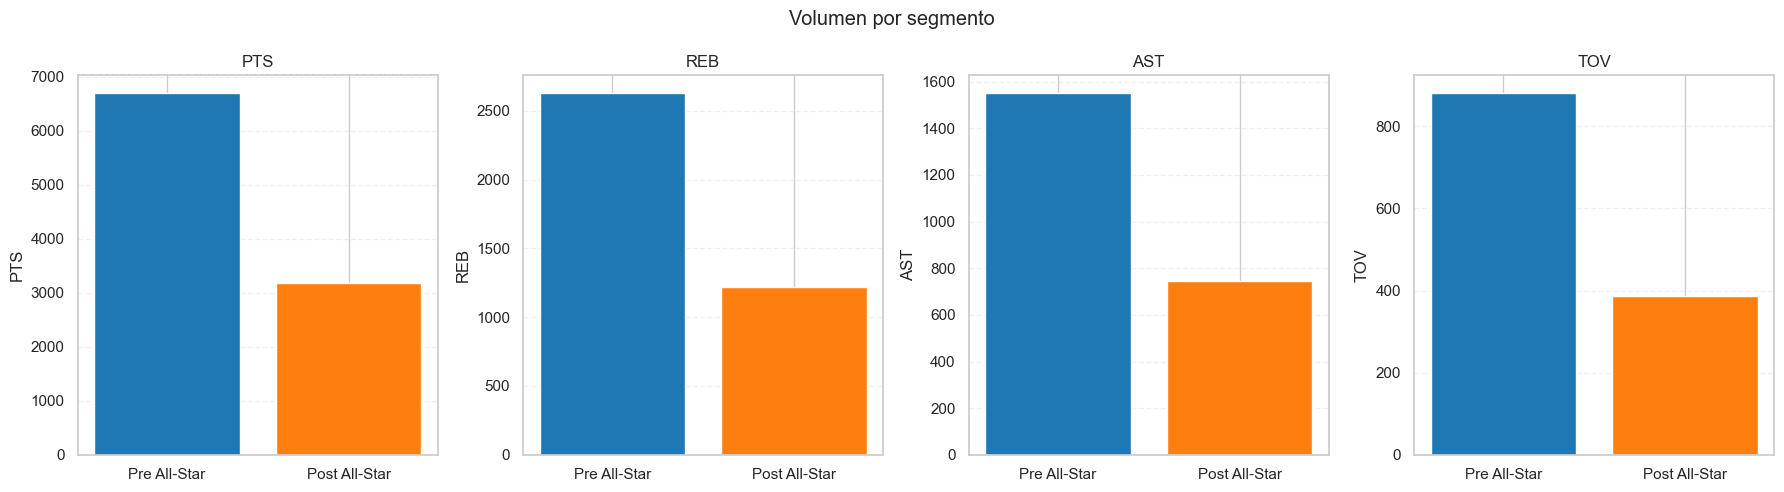

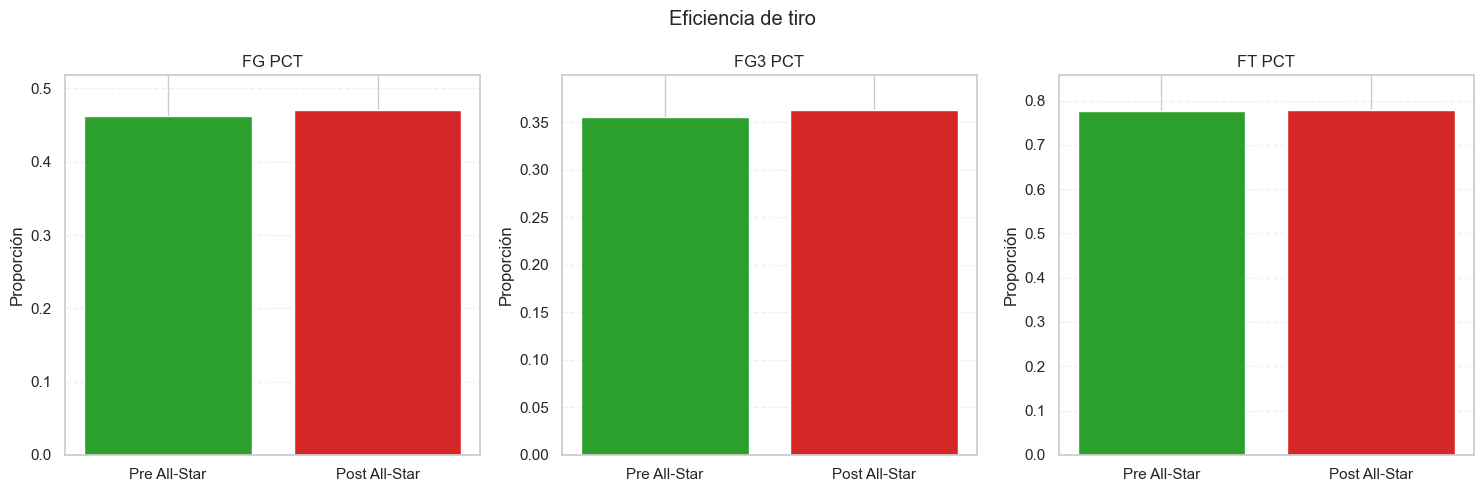

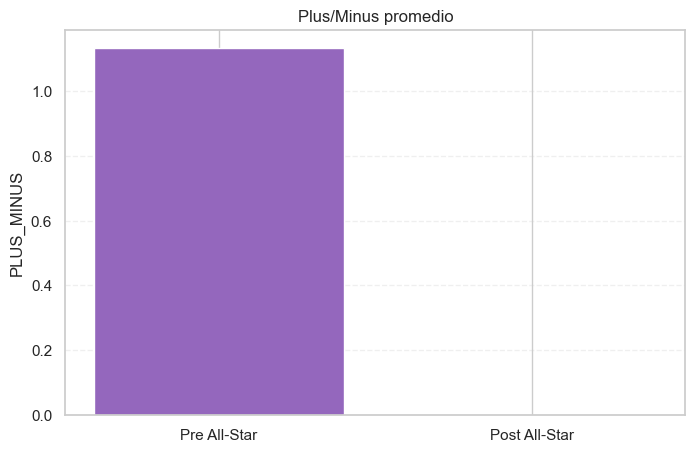

In [9]:
plot_order = [seg for seg in segment_order if seg in segment_summary.index]
plot_data = segment_summary.loc[plot_order]

if not plot_data.empty:
    # Volumen ofensivo y control
    fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
    volume_metrics = ["PTS", "REB", "AST", "TOV"]
    for ax, metric in zip(axes, volume_metrics):
        if metric in plot_data.columns:
            ax.bar(plot_data.index, plot_data[metric], color=["#1f77b4", "#ff7f0e"][: len(plot_data.index)])
            ax.set_title(metric)
            ax.set_ylabel(metric)
            ax.grid(axis="y", linestyle="--", alpha=0.3)
    fig.suptitle("Volumen por segmento")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "volume_metrics_pre_post_allstar.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Porcentajes de tiro
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
    pct_metrics = ["FG_PCT", "FG3_PCT", "FT_PCT"]
    for ax, metric in zip(axes, pct_metrics):
        if metric in plot_data.columns:
            ax.bar(plot_data.index, plot_data[metric], color=["#2ca02c", "#d62728"][: len(plot_data.index)])
            ax.set_title(metric.replace("_", " "))
            ax.set_ylabel("Proporción")
            ax.set_ylim(0, max(plot_data[metric].max() * 1.1, 0.1))
            ax.grid(axis="y", linestyle="--", alpha=0.3)
    fig.suptitle("Eficiencia de tiro")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "shooting_metrics_pre_post_allstar.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Plus/minus
    if "PLUS_MINUS" in plot_data.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(plot_data.index, plot_data["PLUS_MINUS"], color=["#9467bd", "#8c564b"][: len(plot_data.index)])
        ax.set_ylabel("PLUS_MINUS")
        ax.set_title("Plus/Minus promedio")
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        fig.savefig(FIGURES_DIR / "plus_minus_pre_post_allstar.png", dpi=200, bbox_inches="tight")
        plt.show()
else:
    print("No hay datos suficientes para graficar.")


## Deltas Post – Pre

Calculamos la variación absoluta (`post − pre`) para todas las métricas analizadas y, cuando aplica, el porcentaje de cambio (`(post/pre − 1) * 100`). La tabla se ordena por impacto absoluto.

---


In [10]:
if set(segment_order).issubset(segment_summary.index):
    pre_values = segment_summary.loc["Pre All-Star"]
    post_values = segment_summary.loc["Post All-Star"]
    delta = (post_values - pre_values).to_frame(name="delta")
    delta["abs_delta"] = delta["delta"].abs()

    pct_metrics = ["PTS", "REB", "AST", "TOV"]
    for metric in pct_metrics:
        if metric in segment_summary.columns and pre_values.get(metric) not in (0, None):
            base = pre_values.get(metric)
            delta.loc[metric, "pct_change"] = ((post_values.get(metric) / base) - 1) * 100 if base else None

    delta_sorted = delta.sort_values("abs_delta", ascending=False)
    display(delta_sorted.round({"delta": 3, "abs_delta": 3, "pct_change": 2}))

    delta_path = TABLES_DIR / "delta_post_vs_pre_allstar.parquet"
    delta_sorted.to_parquet(delta_path)
    print(f"Tabla guardada en: {delta_path}")
else:
    print("No se puede calcular delta: falta segmento Pre o Post.")


,delta,abs_delta,pct_change
PTS,-3510.533,3510.533,-52.47
MIN,-1519.103,1519.103,NaN
REB,-1404.333,1404.333,-53.49
AST,-806.433,806.433,-52.04
TOV,-493.000,493.000,-56.01
PLUS_MINUS,-1.133,1.133,NaN
FG_PCT,0.009,0.009,NaN
FG3_PCT,0.008,0.008,NaN
FT_PCT,0.002,0.002,NaN
W_PCT,0.001,0.001,NaN


Tabla guardada en: /Users/pablo/Documents/BigData/BasketballAnalysis/02a_reports/tables/pre_post_allstar/delta_post_vs_pre_allstar.parquet


## Contexto adicional (ranks)

Cuando existen columnas de ranking, mostramos la media para `W_PCT_RANK`, `PTS_RANK`, `FG_PCT_RANK` y `FG3_PCT_RANK` según el segmento.

---


In [11]:
rank_candidates = ["W_PCT_RANK", "PTS_RANK", "FG_PCT_RANK", "FG3_PCT_RANK"]
available_ranks = []
for col in rank_candidates:
    key = col.lower()
    if key in col_lookup:
        available_ranks.append(col)

if available_ranks:
    rank_cols = [get_col(col) for col in available_ranks]
    rank_summary = (
        df_seg
        .groupby(SEG_COLUMN)[rank_cols]
        .mean(numeric_only=True)
        .rename(columns={get_col(col): col for col in available_ranks})
        .reindex(segment_order)
        .round(2)
    )
    display(rank_summary)
else:
    print("No hay columnas de ranking disponibles en el dataset.")


,W_PCT_RANK,PTS_RANK,FG_PCT_RANK,FG3_PCT_RANK
SEG,,,,
Pre All-Star,1.57,1.0,1.7,1.6
Post All-Star,1.43,2.0,1.3,1.4


## Conclusiones

- Diferencias principales en volumen ofensivo y rebote tras el All-Star, destacando qué métricas crecen o disminuyen.
- Evaluación de la eficiencia de tiro (`FG%`, `FG3%`, `FT%`) para determinar si los cambios responden a puntería o selección de tiros.
- Análisis de asistencias vs pérdidas para entender la calidad de la circulación de balón post pausa.
- Observación del diferencial `PLUS_MINUS` junto al `W_PCT` para inferir impacto en resultados colectivos.
- Referencia a los rankings disponibles para contextualizar el rendimiento relativo frente al resto de la liga.
